In [1]:
# Importing libraries for data manipulation and analysis  
import pandas as pd  
import numpy as np  


In [2]:
# Importing utilities for mathematical operations, warnings, and string manipulation  
import math  
import warnings  
import string  


In [3]:
# Importing Matplotlib for data visualization and customization  
import matplotlib.pyplot as plt  
from matplotlib.legend_handler import HandlerLine2D  


In [4]:
# Importing preprocessing tools for feature scaling and transformation  
from sklearn.preprocessing import StandardScaler  
from sklearn.preprocessing import MinMaxScaler  

# Importing statistical modeling libraries for detailed analysis  
import statsmodels.api as sm  
import statsmodels.formula.api as smf  


In [5]:
# Importing libraries for various machine learning models and evaluation metrics  

# Logistic Regression for binary classification  
from sklearn.linear_model import LogisticRegression  

# Decision Tree for non-linear decision boundaries  
from sklearn.tree import DecisionTreeClassifier  

# Gradient Boosting for ensemble-based learning  
from sklearn.ensemble import GradientBoostingClassifier  

# Random Forest for ensemble-based decision trees  
from sklearn.ensemble import RandomForestClassifier  

# K-Nearest Neighbors for instance-based learning  
from sklearn.neighbors import KNeighborsClassifier  

# Support Vector Classifier for high-dimensional data classification  
from sklearn import svm  
from sklearn.svm import LinearSVC  


In [68]:
# Importing tools for data splitting, cross-validation, and hyperparameter tuning  
from sklearn.model_selection import train_test_split  
from sklearn.model_selection import GridSearchCV  
from sklearn.model_selection import cross_validate  
from sklearn.model_selection import KFold  
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer, KNNImputer

# Importing metrics for model evaluation  
from sklearn.metrics import confusion_matrix, classification_report  
from sklearn.metrics import accuracy_score  
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  


In [7]:
# Linear Discriminant Analysis (LDA) for dimensionality reduction and classification  
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis   

# Feature selection using Sequential Feature Selector  
from sklearn.feature_selection import SequentialFeatureSelector  


In [8]:
# Seaborn for advanced data visualization and styling  
import seaborn as sns  

# Suppressing warnings to keep the output clean  
warnings.filterwarnings("ignore")  


In [9]:
# Loading the dataset from a CSV file with a semicolon as the delimiter
my_data = pd.read_csv(r'C:\Users\haann\Downloads\cardio.csv', delimiter=';')

# Displaying the first few rows of the dataset to understand its structure
my_data.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [10]:
my_data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [11]:
# Dropping the 'id' column as it is not relevant for analysis
my_data.drop('id', axis=1, inplace=True)

# Displaying the first few rows of the updated dataset to confirm the change
my_data.head()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [12]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


In [13]:
my_data.size 

840000

In [14]:
# Checking for missing values in the dataset by summing up all NaN entries
print(my_data.isna().sum().sum())

0


In [15]:
# Checking for duplicate records in the dataset by summing up all duplicate entries
print(my_data.duplicated().sum())


24


In [16]:
my_data_2= my_data.copy()

In [17]:
# Removing duplicate records from the dataset to ensure data integrity
my_data_2.drop_duplicates(inplace=True)


In [18]:
my_data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [19]:
my_data.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
my_data_2


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [21]:
# Generating a statistical summary of the dataset to understand key metrics (mean, std, min, max, etc.)
my_data_2.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,19468.950126,1.349648,164.359152,74.208519,128.820453,96.636261,1.366997,1.226535,0.088159,0.053790,0.803718,0.499771
std,2467.374620,0.476862,8.211218,14.397211,154.037729,188.504581,0.680333,0.572353,0.283528,0.225604,0.397187,0.500004
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
# Converting the 'age' column from days to years by dividing by 365
my_data_2['age'] = my_data_2['age'] / 365


In [23]:
my_data_2.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,53.339589,1.349648,164.359152,74.208519,128.820453,96.636261,1.366997,1.226535,0.088159,0.053790,0.803718,0.499771
std,6.759930,0.476862,8.211218,14.397211,154.037729,188.504581,0.680333,0.572353,0.283528,0.225604,0.397187,0.500004
min,29.583562,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.394521,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.980822,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.430137,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.967123,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
my_data_3 = my_data_2.copy()


In [25]:
# Step 1: Apply domain-specific filtering
# - Systolic blood pressure (ap_hi) should be higher than diastolic blood pressure (ap_lo)
# - Both values should be positive and within reasonable ranges
# - Set unrealistic values to NaN for further cleaning

# Filtering ap_hi values greater than 350 and ap_lo values greater than 250
my_data_3.loc[my_data_3['ap_hi'] > 350, 'ap_hi'] = np.nan
my_data_3.loc[my_data_3['ap_lo'] > 250, 'ap_lo'] = np.nan

# Filtering out negative values for both ap_hi and ap_lo
my_data_3.loc[my_data_3['ap_hi'] < 0, 'ap_hi'] = np.nan
my_data_3.loc[my_data_3['ap_lo'] < 0, 'ap_lo'] = np.nan

# Ensuring that systolic pressure (ap_hi) is greater than diastolic pressure (ap_lo)
my_data_3.loc[my_data_3['ap_hi'] <= my_data_3['ap_lo'], 'ap_hi'] = np.nan
my_data_3.loc[my_data_3['ap_hi'] <= my_data_3['ap_lo'], 'ap_lo'] = np.nan

# Step 2: Apply IQR-based filtering
# - Calculate the Interquartile Range (IQR) for both ap_hi and ap_lo
# - Remove values outside of the acceptable range (1.5 * IQR from the 5th and 95th percentiles)

for col in ['ap_hi', 'ap_lo']:
    Q1 = my_data_3[col].quantile(0.05)  # 5th percentile of the feature
    Q3 = my_data_3[col].quantile(0.95)  # 95th percentile of the feature
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    
    # Set outliers as NaN for further handling
    my_data_3.loc[my_data_3[col] < lower, col] = np.nan
    my_data_3.loc[my_data_3[col] > upper, col] = np.nan

# Check the final dataset to ensure the cleaning process
print(my_data_3.info())


<class 'pandas.core.frame.DataFrame'>
Index: 69976 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          69976 non-null  float64
 1   gender       69976 non-null  int64  
 2   height       69976 non-null  int64  
 3   weight       69976 non-null  float64
 4   ap_hi        69651 non-null  float64
 5   ap_lo        68940 non-null  float64
 6   cholesterol  69976 non-null  int64  
 7   gluc         69976 non-null  int64  
 8   smoke        69976 non-null  int64  
 9   alco         69976 non-null  int64  
 10  active       69976 non-null  int64  
 11  cardio       69976 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 6.9 MB
None


In [26]:
# Checking the number of NaN values in the 'ap_hi' and 'ap_lo' columns to assess the data quality
print("NaN values in ap_hi:", my_data_3['ap_hi'].isna().sum())
print("NaN values in ap_lo:", my_data_3['ap_lo'].isna().sum())


NaN values in ap_hi: 325
NaN values in ap_lo: 1036


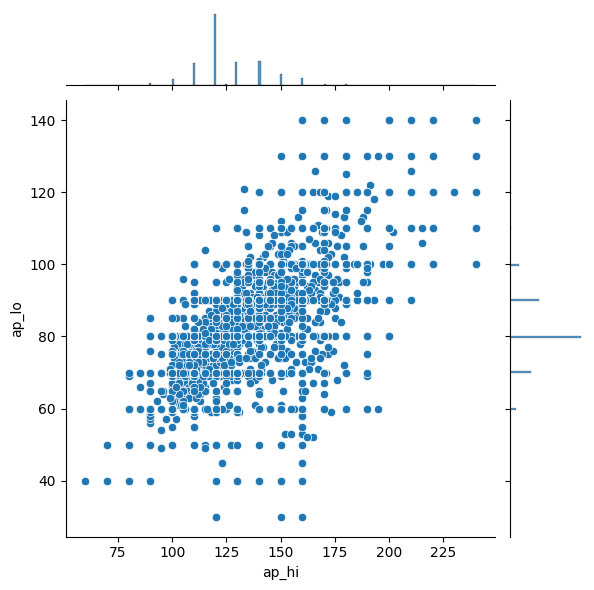

In [27]:
# Dropping rows with NaN values in 'ap_hi' and 'ap_lo' columns to ensure clean data for visualization
my_data_3_clean = my_data_3.dropna(subset=['ap_hi', 'ap_lo'])

# Creating a jointplot to visualize the relationship between 'ap_hi' (systolic) and 'ap_lo' (diastolic)
sns.jointplot(x='ap_hi', y='ap_lo', data=my_data_3_clean);


In [28]:
my_data_4 = my_data_3.copy()


In [29]:
# Step 1: Apply domain-specific filtering
# - Remove implausible height values based on known human height limits
# - Set height values less than 55 to NaN (implausibly short)
my_data_4.loc[my_data_4['height'] < 55, 'height'] = np.nan

# - Set height values greater than 272 to NaN (implausibly tall)
my_data_4.loc[my_data_4['height'] > 272, 'height'] = np.nan

# Step 2: Apply IQR-based filtering for 'height' and 'weight'
# - Calculate the Interquartile Range (IQR) for both 'height' and 'weight'
# - Remove values outside of the acceptable range (1.5 * IQR from the 5th and 95th percentiles)

for col in ['height', 'weight']:
    Q1 = my_data_4[col].quantile(0.05)  # 5th percentile of the feature
    Q3 = my_data_4[col].quantile(0.95)  # 95th percentile of the feature
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    
    # Set outliers as NaN for further handling
    my_data_4.loc[my_data_4[col] < lower, col] = np.nan
    my_data_4.loc[my_data_4[col] > upper, col] = np.nan

# Check the final dataset after cleaning
print(my_data_4.info())


<class 'pandas.core.frame.DataFrame'>
Index: 69976 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          69976 non-null  float64
 1   gender       69976 non-null  int64  
 2   height       69927 non-null  float64
 3   weight       69954 non-null  float64
 4   ap_hi        69651 non-null  float64
 5   ap_lo        68940 non-null  float64
 6   cholesterol  69976 non-null  int64  
 7   gluc         69976 non-null  int64  
 8   smoke        69976 non-null  int64  
 9   alco         69976 non-null  int64  
 10  active       69976 non-null  int64  
 11  cardio       69976 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.9 MB
None


In [30]:
# Checking the number of NaN values in 'height' and 'weight' columns to assess the data quality after filtering
print("NaN values in height:", my_data_4['height'].isna().sum())
print("NaN values in weight:", my_data_4['weight'].isna().sum())


NaN values in height: 49
NaN values in weight: 22


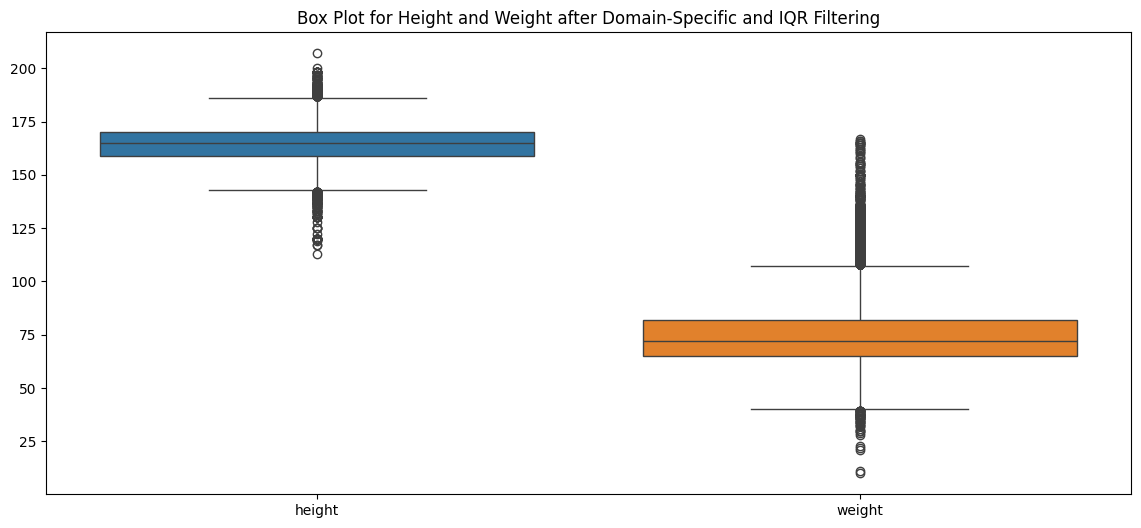

In [31]:
# Dropping rows with NaN values in 'height' and 'weight' for visualization purposes
# This ensures that the boxplot is created only using valid data
my_data_4_clean = my_data_4.dropna(subset=['height', 'weight'])

# Create the boxplot for the cleaned data to visualize the distribution of 'height' and 'weight'
# The boxplot helps identify the spread, median, and potential remaining outliers in the data
plt.figure(figsize=(14, 6))  # Set the figure size for better visualization
sns.boxplot(data=my_data_4_clean[['height', 'weight']], showfliers=True)  # showfliers=True displays any remaining outliers
plt.title('Box Plot for Height and Weight after Domain-Specific and IQR Filtering')  # Title for the plot
plt.show()  # Display the plot


In [32]:
my_data_4.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,69976.000000,69976.000000,69927.000000,69954.000000,69651.000000,68940.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,53.339589,1.349648,164.411257,74.176163,127.053797,81.344415,1.366997,1.226535,0.088159,0.053790,0.803718,0.499771
std,6.759930,0.476862,7.935087,14.282545,17.062495,9.546580,0.680333,0.572353,0.283528,0.225604,0.397187,0.500004
min,29.583562,1.000000,113.000000,10.000000,12.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.394521,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.980822,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.430137,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.967123,2.000000,207.000000,167.000000,240.000000,140.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
# We can create a new feature 'BMI' (Body Mass Index) using height and weight. 
# It might lead to better insights, as BMI indicates whether a person is in normal health or not.
# The formula to calculate BMI is:

# BMI = weight (kg) / height^2 (m^2)

# Where:
# - weight is the person's weight in kilograms
# - height is the person's height in meters, so it must be converted from centimeters to meters

# Calculating BMI for each patient
my_data_4['BMI'] = round(my_data_4['weight']/((my_data_4['height']/100)**2), 1)

# Displaying the first few rows of the dataset with the new 'BMI' column
my_data_4.head()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50.391781,2,168.0,62.0,110.0,80.0,1,1,0,0,1,0,22.0
1,55.419178,1,156.0,85.0,140.0,90.0,3,1,0,0,1,1,34.9
2,51.663014,1,165.0,64.0,130.0,70.0,3,1,0,0,0,1,23.5
3,48.282192,2,169.0,82.0,150.0,100.0,1,1,0,0,1,1,28.7
4,47.873973,1,156.0,56.0,100.0,60.0,1,1,0,0,0,0,23.0


In [34]:
# Replacing extreme BMI values with NaN
# We are considering BMI values below 10 and above 60 as extreme or unrealistic.
# These values are replaced with NaN to clean the data and ensure more accurate analysis.
my_data_4.loc[(my_data_4['BMI'] < 10) | (my_data_4['BMI'] > 60), 'BMI'] = np.nan

# Displaying the dataset info to check the impact of the operation
# This will show the number of non-null entries and data types of all columns.
print(my_data_4.info())


<class 'pandas.core.frame.DataFrame'>
Index: 69976 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          69976 non-null  float64
 1   gender       69976 non-null  int64  
 2   height       69927 non-null  float64
 3   weight       69954 non-null  float64
 4   ap_hi        69651 non-null  float64
 5   ap_lo        68940 non-null  float64
 6   cholesterol  69976 non-null  int64  
 7   gluc         69976 non-null  int64  
 8   smoke        69976 non-null  int64  
 9   alco         69976 non-null  int64  
 10  active       69976 non-null  int64  
 11  cardio       69976 non-null  int64  
 12  BMI          69882 non-null  float64
dtypes: float64(6), int64(7)
memory usage: 7.5 MB
None


In [35]:
print("NaN values in BMI:", my_data_4['BMI'].isna().sum())


NaN values in BMI: 94


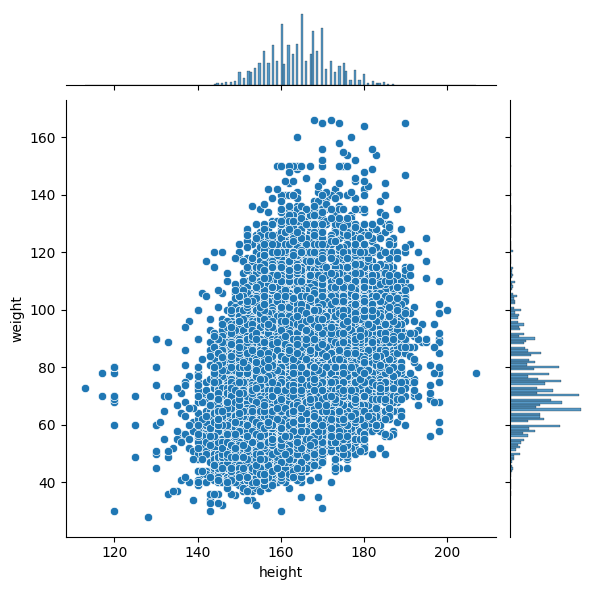

In [36]:
# Dropping rows with NaN values in the 'BMI', 'height', and 'weight' columns
# This ensures that the data used for visualization is clean and doesn't contain missing values.
my_data_alpha = my_data_4.dropna(subset= ['BMI', 'height', 'weight'])

# Creating a jointplot to visualize the relationship between height and weight
# The jointplot will show both the scatter plot and the distribution of each variable (height and weight).
sns.jointplot(x='height', y='weight', data=my_data_alpha);


In [37]:
my_data_4


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50.391781,2,168.0,62.0,110.0,80.0,1,1,0,0,1,0,22.0
1,55.419178,1,156.0,85.0,140.0,90.0,3,1,0,0,1,1,34.9
2,51.663014,1,165.0,64.0,130.0,70.0,3,1,0,0,0,1,23.5
3,48.282192,2,169.0,82.0,150.0,100.0,1,1,0,0,1,1,28.7
4,47.873973,1,156.0,56.0,100.0,60.0,1,1,0,0,0,0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52.712329,2,168.0,76.0,120.0,80.0,1,1,1,0,1,0,26.9
69996,61.920548,1,158.0,126.0,140.0,90.0,2,2,0,0,1,1,50.5
69997,52.235616,2,183.0,105.0,180.0,90.0,3,1,0,1,0,1,31.4
69998,61.454795,1,163.0,72.0,135.0,80.0,1,2,0,0,0,1,27.1


In [39]:
print("NaN values in gender:", my_data_4['gender'].isna().sum())


NaN values in gender: 0


[Text(0, 0, 'Female'), Text(1, 0, 'Male')]

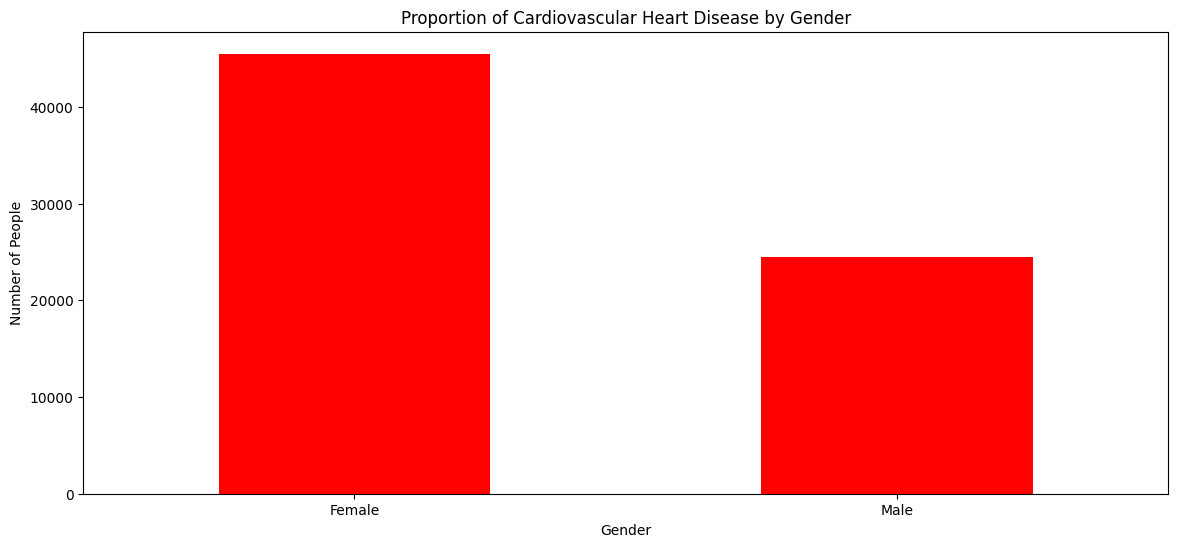

In [40]:
# Counting the number of occurrences of each gender in the dataset
# This will give us the distribution of cardiovascular heart disease by gender.
gender = my_data_4['gender'].value_counts()

# Creating a bar plot to visualize the distribution of cardiovascular heart disease by gender
plt.figure(figsize=(14, 6))  # Setting the figure size for better visibility
ax = gender.plot(kind='bar', rot=0, color="r")  # Plotting a bar chart with red color
ax.set_title("Proportion of Cardiovascular Heart Disease by Gender", y=1)  # Setting the title of the plot
ax.set_xlabel('Gender')  # Labeling the x-axis as 'Gender'
ax.set_ylabel('Number of People')  # Labeling the y-axis as 'Number of People'
ax.set_xticklabels(('Female', 'Male'))  # Labeling the x-tick marks as 'Female' and 'Male'


[Text(0, 0, 'Normal'),
 Text(1, 0, 'Above Normal'),
 Text(2, 0, 'Well Above Normal')]

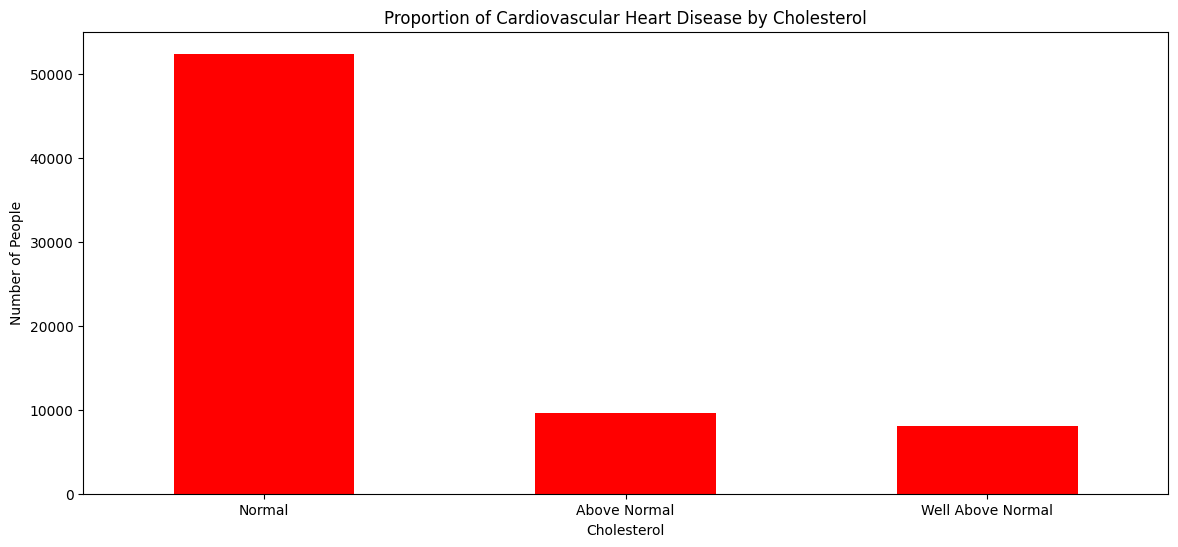

In [41]:
cholesterol = my_data_4['cholesterol'].value_counts()
plt.figure(figsize=(14, 6))
ax = cholesterol.plot(kind='bar', rot=0, color="r")
ax.set_title("Proportion of Cardiovascular Heart Disease by Cholesterol", y=1)
ax.set_xlabel('Cholesterol')
ax.set_ylabel('Number of People')
ax.set_xticklabels(('Normal', 'Above Normal', 'Well Above Normal'))

[Text(0, 0, 'Normal'),
 Text(1, 0, 'Above Normal'),
 Text(2, 0, 'Well Above Normal')]

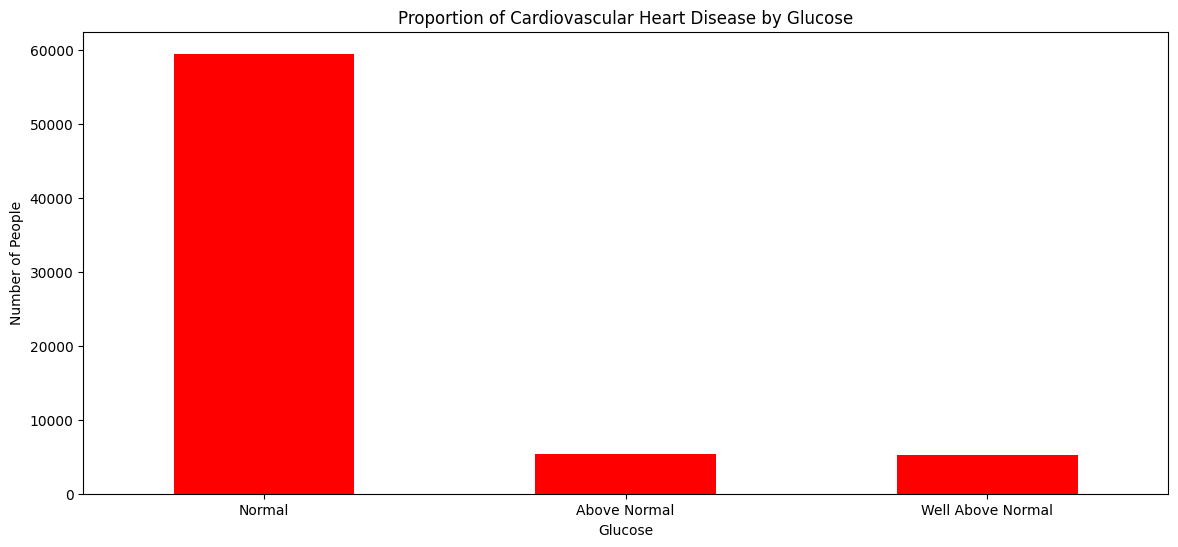

In [42]:
gluc = my_data_4['gluc'].value_counts()
plt.figure(figsize=(14, 6))
ax = gluc.plot(kind='bar', rot=0, color="r")
ax.set_title("Proportion of Cardiovascular Heart Disease by Glucose", y=1)
ax.set_xlabel('Glucose')
ax.set_ylabel('Number of People')
ax.set_xticklabels(('Normal', 'Above Normal', 'Well Above Normal'))

[Text(0, 0, 'Yes'), Text(1, 0, 'No')]

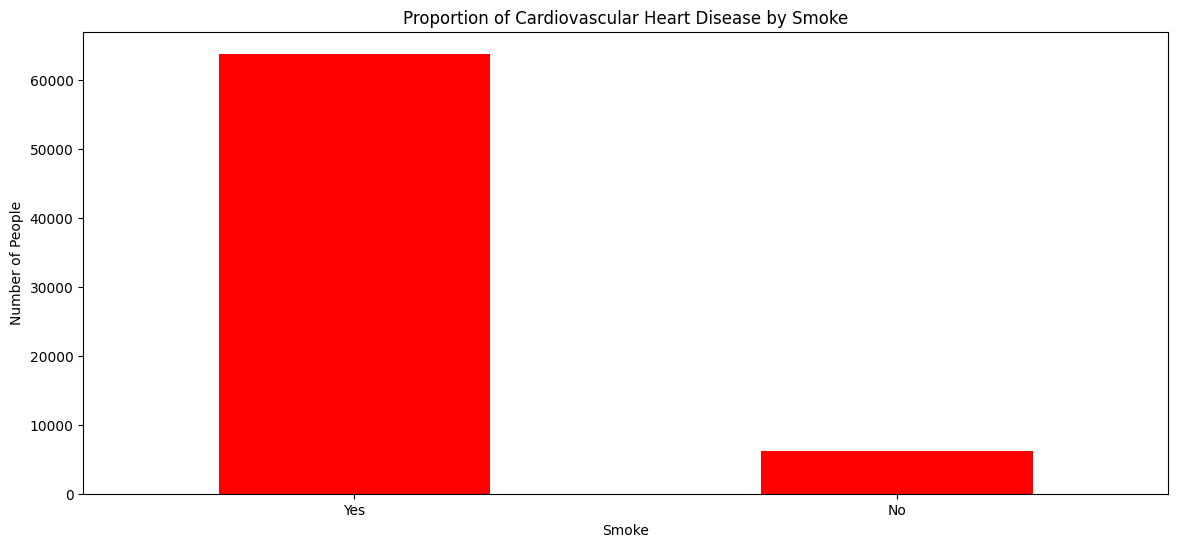

In [43]:
smoke = my_data_4['smoke'].value_counts()
plt.figure(figsize=(14, 6))
ax = smoke.plot(kind='bar', rot=0, color="r")
ax.set_title("Proportion of Cardiovascular Heart Disease by Smoke", y=1)
ax.set_xlabel('Smoke')
ax.set_ylabel('Number of People')
ax.set_xticklabels(('Yes', 'No'))

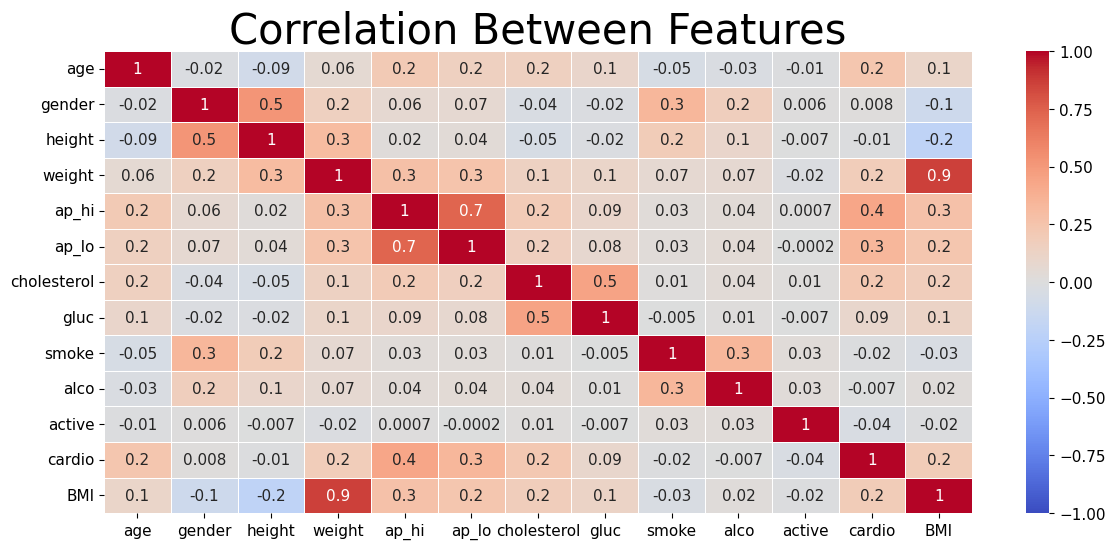

In [44]:
# Feature Engineering
# Creating a copy of the dataset to avoid modifying the original data
data_copy = my_data_4.copy()

# Plotting the correlation heatmap to visualize the relationships between features
# The correlation map helps in understanding how different features are related to each other
# A high correlation between independent features means they convey similar information, so one might be dropped without losing much valuable data.
plt.rcParams.update({'font.size': 11})  # Update the font size for better readability of the plot

# Create a figure and axis object for plotting the heatmap
fig, ax = plt.subplots(figsize=(14, 6))  # Setting the size of the plot for better visualization

# Plot the heatmap
sns.heatmap(data_copy.corr(), 
            annot=True,           # Annotate the heatmap with correlation values
            vmin=-1, vmax=1,      # Set the color scale range from -1 to 1
            center=0,             # Set the center value of the color scale to 0
            cmap='coolwarm',      # Use the 'coolwarm' color map for the heatmap
            ax=ax,                # Plot on the created axis
            fmt='.1g',            # Format the annotation values to 1 significant digit
            linewidths=.5)        # Set the linewidths between the cells for clarity

# Set the title of the heatmap
plt.title('Correlation Between Features', fontsize=30)

# Display the plot
plt.show()


In [45]:
"""
Observations:

    Age and cholesterol: Have a significant impact but aren't strongly correlated with the target.

    Systolic and diastolic blood pressure (ap_hi and ap_lo): Strongly correlated with the target and have a significant impact.

    BMI: Has a high correlation with weight but a weak correlation with the target, suggesting that one of the features might be dropped.
    
    Gender, smoke, and height: Have the least correlation with the target.
"""

"\nObservations:\n\n    Age and cholesterol: Have a significant impact but aren't strongly correlated with the target.\n\n    Systolic and diastolic blood pressure (ap_hi and ap_lo): Strongly correlated with the target and have a significant impact.\n\n    BMI: Has a high correlation with weight but a weak correlation with the target, suggesting that one of the features might be dropped.\n    \n    Gender, smoke, and height: Have the least correlation with the target.\n"

In [46]:
my_data_4


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50.391781,2,168.0,62.0,110.0,80.0,1,1,0,0,1,0,22.0
1,55.419178,1,156.0,85.0,140.0,90.0,3,1,0,0,1,1,34.9
2,51.663014,1,165.0,64.0,130.0,70.0,3,1,0,0,0,1,23.5
3,48.282192,2,169.0,82.0,150.0,100.0,1,1,0,0,1,1,28.7
4,47.873973,1,156.0,56.0,100.0,60.0,1,1,0,0,0,0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52.712329,2,168.0,76.0,120.0,80.0,1,1,1,0,1,0,26.9
69996,61.920548,1,158.0,126.0,140.0,90.0,2,2,0,0,1,1,50.5
69997,52.235616,2,183.0,105.0,180.0,90.0,3,1,0,1,0,1,31.4
69998,61.454795,1,163.0,72.0,135.0,80.0,1,2,0,0,0,1,27.1


In [47]:
my_data_scaled= my_data_4.copy()


In [50]:
# Columns to be imputed, scaled, and not scaled
columns_to_impute = ['height', 'weight', 'ap_hi', 'ap_lo', 'BMI']
columns_to_scale = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'BMI']
columns_no_scale = ['smoke', 'active', 'alco', 'cardio']

# Step 1: Imputation
# Imputers for each column
imputation_strategies = {
    'height': SimpleImputer(strategy='mean'),  # Impute height with mean
    'weight': KNNImputer(n_neighbors=10),  # Impute weight using KNN with 10 neighbors
    'ap_hi': KNNImputer(n_neighbors=10),  # Impute systolic blood pressure using KNN
    'ap_lo': KNNImputer(n_neighbors=10),  # Impute diastolic blood pressure using KNN
    'BMI': SimpleImputer(strategy='median')  # Impute BMI using median
}

# Apply imputation and transformation to the specified columns
for col, imputer in imputation_strategies.items():
    my_data_scaled[col] = imputer.fit_transform(my_data_scaled[[col]])

# Step 2: Scaling
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Scale only the specified columns
scaled_data = scaler.fit_transform(my_data_scaled[columns_to_scale])

# Create a DataFrame for the scaled columns
scaled_df = pd.DataFrame(scaled_data, columns=columns_to_scale, index=my_data_scaled.index)

# Combine scaled columns with non-scaled columns
final_data = pd.concat([scaled_df, my_data_scaled[columns_no_scale]], axis=1)
final_data = final_data[columns_to_scale + columns_no_scale]  # Reorganize the columns for final dataset


In [51]:
final_data


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,BMI,smoke,active,alco,cardio
0,0.588076,1.0,0.585106,0.331210,0.429825,0.454545,0.0,0.0,0.231557,0,1,0,0
1,0.730159,0.0,0.457447,0.477707,0.561404,0.545455,1.0,0.0,0.495902,0,1,0,1
2,0.624003,0.0,0.553191,0.343949,0.517544,0.363636,1.0,0.0,0.262295,0,0,0,1
3,0.528455,1.0,0.595745,0.458599,0.605263,0.636364,0.0,0.0,0.368852,0,1,0,1
4,0.516918,0.0,0.457447,0.292994,0.385965,0.272727,0.0,0.0,0.252049,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.653659,1.0,0.585106,0.420382,0.473684,0.454545,0.0,0.0,0.331967,1,1,0,0
69996,0.913899,0.0,0.478723,0.738854,0.561404,0.545455,0.5,0.5,0.815574,0,1,0,1
69997,0.640186,1.0,0.744681,0.605096,0.736842,0.545455,1.0,0.0,0.424180,0,0,1,1
69998,0.900736,0.0,0.531915,0.394904,0.539474,0.454545,0.0,0.5,0.336066,0,0,0,1


In [52]:
print(final_data.isna().sum().sum()) 


0


In [53]:
final_data.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,BMI,smoke,active,alco,cardio
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,0.671386,0.349648,0.546928,0.408765,0.504622,0.466767,0.183499,0.113267,0.343646,0.088159,0.803718,0.053790,0.499771
std,0.191047,0.476862,0.084386,0.090957,0.074662,0.086142,0.340167,0.286177,0.106680,0.283528,0.397187,0.225604,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.531630,0.000000,0.489362,0.350318,0.473684,0.454545,0.000000,0.000000,0.270492,0.000000,1.000000,0.000000,0.000000
50%,0.689508,0.000000,0.553191,0.394904,0.473684,0.454545,0.000000,0.000000,0.321721,0.000000,1.000000,0.000000,0.000000
75%,0.815254,1.000000,0.606383,0.458599,0.561404,0.545455,0.500000,0.000000,0.397541,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [54]:
# Train-test-split for scaled data
X = final_data.drop(['cardio'], axis=1)  # Features (excluding the target column 'cardio')
y = final_data['cardio']  # Target feature (cardio)

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)  # 80% training, 20% testing


In [55]:
# Splitted Data
print('X_train shape is ', X_train.shape)
print('X_test shape is ', X_test.shape)
print('y_train shape is ', y_train.shape)
print('y_test shape is ', y_test.shape)


X_train shape is  (55980, 12)
X_test shape is  (13996, 12)
y_train shape is  (55980,)
y_test shape is  (13996,)


Logistic Regression - Accuracy: 0.7269219777079166
Logistic Regression - Sensitivity (TPR): 0.6741605008537279

Logistic Regression - Confusion Matrix 


              precision    recall  f1-score   support

           0       0.70      0.78      0.74      6968
           1       0.76      0.67      0.71      7028

    accuracy                           0.73     13996
   macro avg       0.73      0.73      0.73     13996
weighted avg       0.73      0.73      0.73     13996



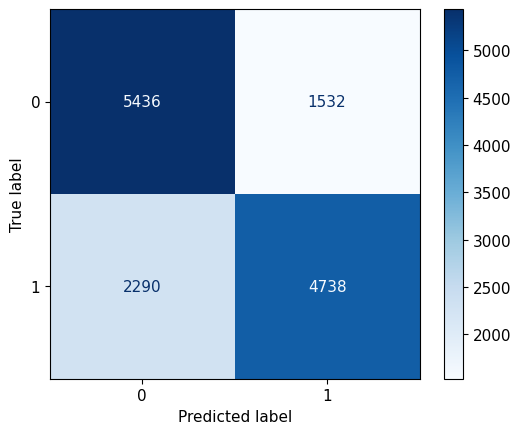

In [56]:
# 1. Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

# Evaluation: Confusion matrix
logreg_acc = accuracy_score(y_test, y_pred_logreg)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)  # Confusion matrix 
tpr_logreg = cm_logreg[1][1] /(cm_logreg[1][0] + cm_logreg[1][1])

print('Logistic Regression - Accuracy:', logreg_acc)  # accuracy score
print('Logistic Regression - Sensitivity (TPR):', tpr_logreg)

print('\nLogistic Regression - Confusion Matrix \n\n')
print(classification_report(y_test, y_pred_logreg))

# Create and plot the confusion matrix display for Logistic Regression
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=logreg.classes_)
disp_logreg.plot(cmap='Blues')  # You can change the color map if needed
plt.show()


In [57]:
# Sequential Forward Selection (SFS)
sfs = SequentialFeatureSelector(LogisticRegression(),
          direction='forward',
          scoring='accuracy',
          cv=5,
          n_jobs=-1)

# Fit the model and select features
sfs.fit(X_train, y_train)

# Print the selected features
print("Features selected by forward sequential selection:", sfs.get_feature_names_out())


Features selected by forward sequential selection: ['age' 'height' 'ap_hi' 'ap_lo' 'cholesterol' 'alco']


The accuracy score is: 0.7256358959702772
Sensitivity (TPR) = 0.6676152532726238

 Confusion matrix 
 

              precision    recall  f1-score   support

           0       0.70      0.78      0.74      6968
           1       0.76      0.67      0.71      7028

    accuracy                           0.73     13996
   macro avg       0.73      0.73      0.72     13996
weighted avg       0.73      0.73      0.72     13996



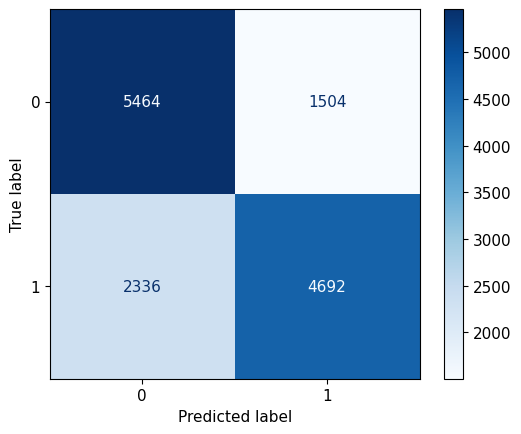

In [58]:
# Train the model after subset selection with selected features
X_train_subset = X_train[sfs.get_feature_names_out()]
X_test_subset = X_test[sfs.get_feature_names_out()]

# Initialize and train Logistic Regression model
logreg_subset = LogisticRegression()
logreg_subset.fit(X_train_subset, y_train)

# Predict the results
y_pred = logreg_subset.predict(X_test_subset)

# Evaluation: Confusion matrix
logreg_acc_subset = accuracy_score(y_test, y_pred)  # Accuracy score
cm_subset = confusion_matrix(y_test, y_pred)  # Confusion matrix 
tpr_logreg_subset = cm_subset[1][1] / (cm_subset[1][0] + cm_subset[1][1])  # True Positive Rate (Sensitivity)

# Print evaluation results
print('The accuracy score is:', logreg_acc_subset)
print('Sensitivity (TPR) =', tpr_logreg_subset)

print('\n Confusion matrix \n \n')
print(classification_report(y_test, y_pred))

# Display confusion matrix
disp_subset = ConfusionMatrixDisplay(confusion_matrix=cm_subset, display_labels=logreg_subset.classes_)
disp_subset.plot(cmap='Blues')  # You can change the color map if needed
plt.show()


In [59]:
# Define the hyperparameter grid
parameters = {
    'penalty' : ['l1', 'l2'],  # Regularization types: L1 (Lasso), L2 (Ridge)
    'C' : [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
}

# Initialize Logistic Regression model
tun_logreg = LogisticRegression()

# GridSearchCV to tune hyperparameters
clf_tun1 = GridSearchCV(tun_logreg,                    # Model
                        param_grid=parameters,       # Hyperparameter grid
                        scoring='accuracy',          # Metric for scoring
                        cv=5,                        # 5-fold cross-validation
                        verbose=3,                   # Show detailed output
                        n_jobs=-1)                   # Use all available CPU cores

# Fit the model on the training data
clf_tun1.fit(X_train, y_train)

# Print the best hyperparameters and accuracy
print("Tuned Hyperparameters:", clf_tun1.best_params_)
print("Accuracy:", clf_tun1.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Tuned Hyperparameters: {'C': 100, 'penalty': 'l2'}
Accuracy: 0.7289746337977849


LDA - Accuracy: 0.7255644469848528
LDA - Sensitivity (TPR): 0.6623505976095617

LDA - Confusion Matrix 


              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6968
           1       0.76      0.66      0.71      7028

    accuracy                           0.73     13996
   macro avg       0.73      0.73      0.72     13996
weighted avg       0.73      0.73      0.72     13996



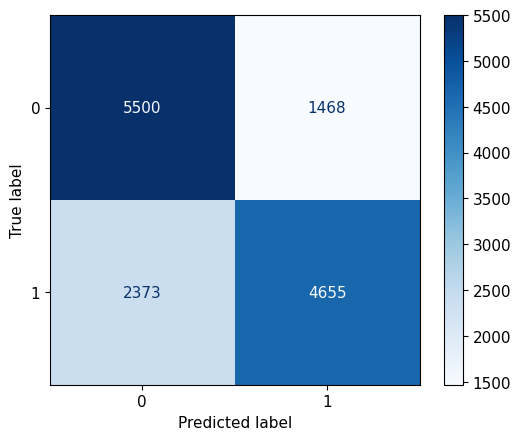

In [60]:
# 2. Linear Discriminant Analysis (LDA)
######################################

# Initialize the Linear Discriminant Analysis model
lda = LinearDiscriminantAnalysis(solver='lsqr', store_covariance=True)
lda.fit(X_train, y_train)

# Predict Test Set Responses
################################
y_pred_lda = lda.predict(X_test)

# Convert the predicted probabilities to class 0 or 1
y_pred_lda = np.array(y_pred_lda > 0.5, dtype=float)

# Evaluation: Confusion matrix
###############################
lda_acc = accuracy_score(y_test, y_pred_lda)  # Accuracy score
cm_lda = confusion_matrix(y_test, y_pred_lda)  # Confusion matrix
tpr_lda = cm_lda[1][1] / (cm_lda[1][0] + cm_lda[1][1])  # Sensitivity (TPR)

# Print the evaluation results for LDA
print('LDA - Accuracy:', lda_acc)
print('LDA - Sensitivity (TPR):', tpr_lda)

# Print confusion matrix and classification report for LDA
print('\nLDA - Confusion Matrix \n\n')
print(classification_report(y_test, y_pred_lda))

# Create and plot the confusion matrix display for LDA
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=lda.classes_)
disp_lda.plot(cmap='Blues')  # You can change the color map if needed
plt.show()


Decision Tree - Accuracy: 0.6349671334667047
Decision Tree - Sensitivity (TPR): 0.6297666476949345

Decision Tree - Confusion Matrix 


              precision    recall  f1-score   support

           0       0.63      0.64      0.64      6968
           1       0.64      0.63      0.63      7028

    accuracy                           0.63     13996
   macro avg       0.63      0.63      0.63     13996
weighted avg       0.64      0.63      0.63     13996



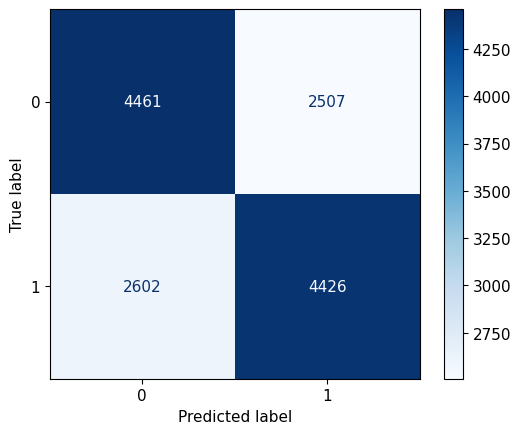

In [61]:
# 3. Decision Tree
dtree = DecisionTreeClassifier(random_state=0)

# Build classification tree
dtree.fit(X_train, y_train)

# Predict Test Set Responses #
##############################
y_pred_dtree = dtree.predict(X_test)

# Evaluation: Confusion matrix #
################################
dtree_acc = accuracy_score(y_test, y_pred_dtree)   # accuracy score
cm_dtree = confusion_matrix(y_test, y_pred_dtree)  # Confusion matrix 
tpr_dtree = cm_dtree[1][1] /(cm_dtree[1][0] + cm_dtree[1][1])

# Displaying results for Decision Tree
print('Decision Tree - Accuracy:', dtree_acc)  
print('Decision Tree - Sensitivity (TPR):', tpr_dtree)

print('\nDecision Tree - Confusion Matrix \n\n')
print(classification_report(y_test, y_pred_dtree))

# Create and plot the confusion matrix display for Decision Tree
disp_dtree = ConfusionMatrixDisplay(confusion_matrix=cm_dtree, display_labels=dtree.classes_)
disp_dtree.plot(cmap='Blues')  # You can change the color map if needed
plt.show()


The maximum validation accuracy is 0.7322092026293227 at max_depth = 5


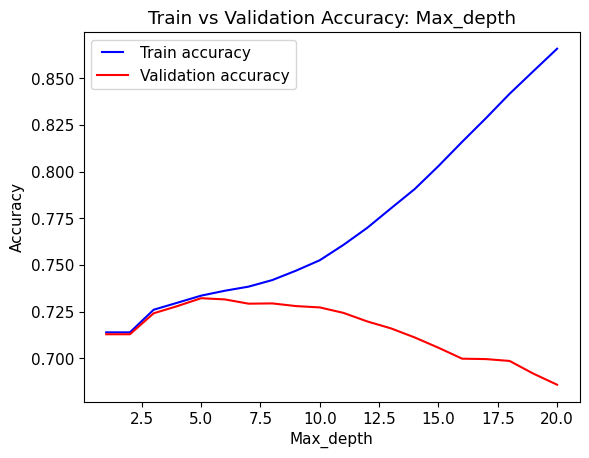

In [63]:
# 3. Hyperparameter Tuning for max_depth (Decision Tree)
train_acc1 = []  # List to store training accuracy for different max_depth values
val_acc1 = []    # List to store validation accuracy for different max_depth values

# Loop to tune max_depth from 1 to 20
for max_d in range(1, 21):
    model = DecisionTreeClassifier(max_depth=max_d, random_state=0)  # Initialize model with max_depth
    model.fit(X_train, y_train)  # Train the model
    train_acc1.append(model.score(X_train, y_train))  # Store training accuracy
    val_acc1.append(model.score(X_test, y_test))  # Store validation accuracy

# After running the loop, find the best max_depth based on validation accuracy
max_val_acc1 = max(val_acc1)  # Get the maximum validation accuracy
max_val_acc1_index = val_acc1.index(max_val_acc1)  # Get the index of the best validation accuracy
best_max_d = range(1, 21)[max_val_acc1_index]  # Get the best max_depth value

print(f"The maximum validation accuracy is {max_val_acc1} at max_depth = {best_max_d}")

# Plotting the train vs validation accuracy for different max_depth values
line1, = plt.plot([*range(1, 21)], train_acc1, 'b', label='Train accuracy')
line2, = plt.plot([*range(1, 21)], val_acc1, 'r', label='Validation accuracy')

plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})  # Add legend
plt.title('Train vs Validation Accuracy: Max_depth')  # Set title for the plot
plt.ylabel('Accuracy')  # Set y-axis label
plt.xlabel('Max_depth')  # Set x-axis label
plt.show()  # Show the plot

# Clear the lists for future use
train_acc1.clear()
val_acc1.clear()


The first maximum validation accuracy is 0.733495284366962 at max_leaf_nodes = 20


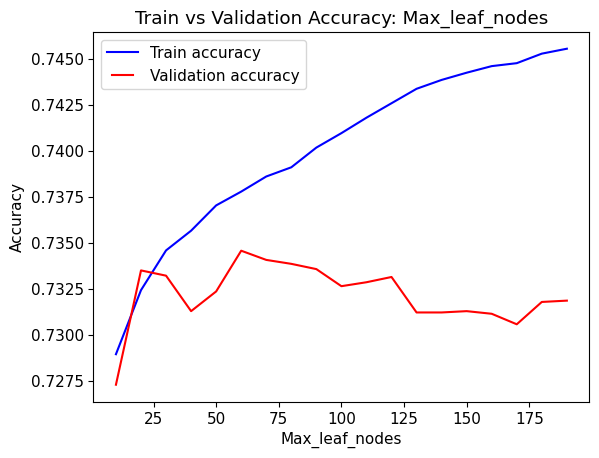

In [64]:
# 3. Hyperparameter Tuning for max_leaf_nodes (Decision Tree)
train_acc2 = []  # List to store training accuracy for different max_leaf_nodes values
val_acc2 = []    # List to store validation accuracy for different max_leaf_nodes values

# Loop to tune max_leaf_nodes from 10 to 200 in steps of 10
for max_ln in range(10, 200, 10):
    model2 = DecisionTreeClassifier(max_leaf_nodes=max_ln, random_state=0)  # Initialize model with max_leaf_nodes
    model2.fit(X_train, y_train)  # Train the model
    train_acc2.append(model2.score(X_train, y_train))  # Store training accuracy
    val_acc2.append(model2.score(X_test, y_test))  # Store validation accuracy

# After running the loop, find the first maximum validation accuracy
max_val_acc2 = max(val_acc2)  # Get the maximum validation accuracy
max_val_acc2_index = val_acc2.index(max_val_acc2)  # Get the index of the best validation accuracy

# Check for the first maximum where the curve first peaks
for i in range(1, len(val_acc2) - 1):
    if val_acc2[i] > val_acc2[i - 1] and val_acc2[i] > val_acc2[i + 1]:
        first_max_index = i  # Store the index of the first maximum
        break

best_max_ln = range(10, 200, 10)[first_max_index]  # Get the best max_leaf_nodes value

print(f"The first maximum validation accuracy is {val_acc2[first_max_index]} at max_leaf_nodes = {best_max_ln}")

# Plotting the train vs validation accuracy for different max_leaf_nodes values
line3, = plt.plot([*range(10, 200, 10)], train_acc2, 'b', label='Train accuracy')
line4, = plt.plot([*range(10, 200, 10)], val_acc2, 'r', label='Validation accuracy')

plt.legend(handler_map={line4: HandlerLine2D(numpoints=2)})  # Add legend
plt.title('Train vs Validation Accuracy: Max_leaf_nodes')  # Set title for the plot
plt.ylabel('Accuracy')  # Set y-axis label
plt.xlabel('Max_leaf_nodes')  # Set x-axis label
plt.show()  # Show the plot

# Clear the lists for future use
train_acc2.clear()
val_acc2.clear()


Decision Tree Tuned - Accuracy: 0.7333523863961132
Decision Tree Tuned - Sensitivity (TPR): 0.6849743881616391

Decision Tree Tuned - Confusion Matrix 


              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6968
           1       0.76      0.68      0.72      7028

    accuracy                           0.73     13996
   macro avg       0.74      0.73      0.73     13996
weighted avg       0.74      0.73      0.73     13996



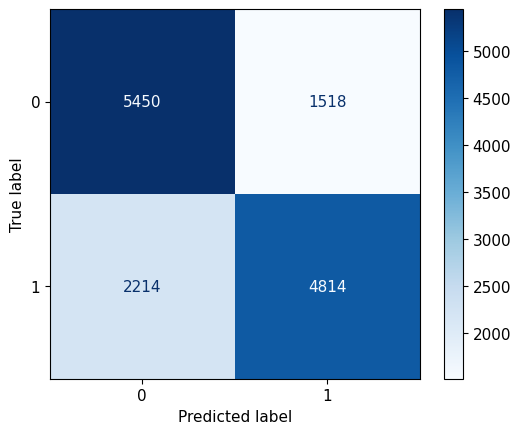

In [65]:
# 3. Decision Tree - Tuned Model (with max_leaf_nodes and max_depth)
# min_samples_split: The minimum number of samples required to split an internal node
dtree_tuned = DecisionTreeClassifier(max_leaf_nodes=20, max_depth=5, random_state=0)  # Initialize tuned Decision Tree model

# Build classification tree
dtree_tuned.fit(X_train, y_train)  # Train the model

y_pred_dtree_tuned = dtree_tuned.predict(X_test)  # Make predictions on the test set

# Evaluation: Confusion matrix #
################################
dtree_tuned_acc = accuracy_score(y_test, y_pred_dtree_tuned)   # accuracy score
cm_dtree_tuned = confusion_matrix(y_test, y_pred_dtree_tuned)  # Confusion matrix 
tpr_dtree_tuned = cm_dtree_tuned[1][1] / (cm_dtree_tuned[1][0] + cm_dtree_tuned[1][1])  # True Positive Rate (Sensitivity)

print("Decision Tree Tuned - Accuracy:", dtree_tuned_acc)  
print('Decision Tree Tuned - Sensitivity (TPR):', tpr_dtree_tuned)

print('\nDecision Tree Tuned - Confusion Matrix \n\n')
print(classification_report(y_test, y_pred_dtree_tuned))  # Print detailed classification report

# Create and plot the confusion matrix display for Decision Tree Tuned model
disp_dtree_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_dtree_tuned, display_labels=dtree_tuned.classes_)
disp_dtree_tuned.plot(cmap='Blues')  # You can change the color map if needed
plt.show()


Gradient Boosting - Accuracy: 0.7362103458130894
Gradient Boosting - Sensitivity (TPR): 0.700199203187251

Gradient Boosting - Confusion Matrix 


              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6968
           1       0.76      0.70      0.73      7028

    accuracy                           0.74     13996
   macro avg       0.74      0.74      0.74     13996
weighted avg       0.74      0.74      0.74     13996



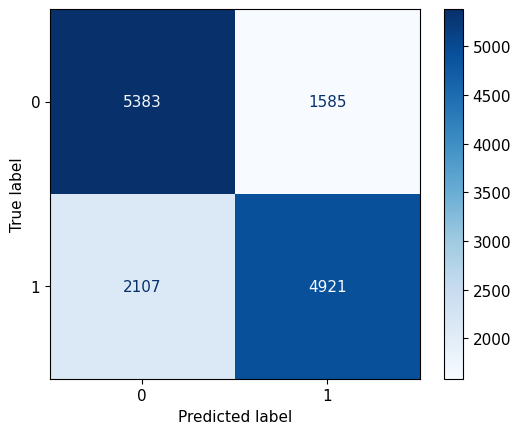

In [66]:
# 4. Gradient Boosting Classifier - Tuned Model
booster = GradientBoostingClassifier(max_depth=7, n_estimators=50, min_samples_split=1400, 
                                     min_samples_leaf=60, max_features=7, subsample=0.85, random_state=0)  # Initialize the Gradient Boosting model

# Train the model
boost_est = booster.fit(X_train, y_train)

y_pred_boost = boost_est.predict(X_test)  # Make predictions on the test set

# Evaluation: Confusion matrix #
################################
boosting_acc = accuracy_score(y_test, y_pred_boost)  # accuracy score
cm_boosting = confusion_matrix(y_test, y_pred_boost)  # Confusion matrix 
tpr_boost = cm_boosting[1][1] / (cm_boosting[1][0] + cm_boosting[1][1])  # True Positive Rate (Sensitivity)

print('Gradient Boosting - Accuracy:', boosting_acc)  # Print accuracy score
print('Gradient Boosting - Sensitivity (TPR):', tpr_boost)  # Print sensitivity (TPR)

print('\nGradient Boosting - Confusion Matrix \n\n')
print(classification_report(y_test, y_pred_boost))  # Print detailed classification report

# Create and plot the confusion matrix display for Gradient Boosting model
disp_boosting = ConfusionMatrixDisplay(confusion_matrix=cm_boosting, display_labels=boost_est.classes_)
disp_boosting.plot(cmap='Blues')  # You can change the color map if needed
plt.show()


In [69]:
# 4. Gradient Boosting Classifier
# Define the model
model = GradientBoostingClassifier(random_state=0)

# Define the evaluation method (commented out as an alternative method)
# cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# Evaluate the model on the dataset using cross-validation
n_scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=5, n_jobs=-1)

# Report performance (mean accuracy and standard deviation)
print("%0.5f accuracy with a standard deviation of %0.2f" % (n_scores.mean(), n_scores.std()))


0.73598 accuracy with a standard deviation of 0.00


In [70]:
# 5. K-Nearest Neighbors (KNN)
# Creating classifiers for every value of K
classifiers = []
nb_neighbor = [1, 5, 10, 20, 30, 40, 50]
for i in range(len(nb_neighbor)):
    classifiers.append(KNeighborsClassifier(nb_neighbor[i]))

# Initializing the lists for accuracy, true positive rate, and true negative rate
# These are later used to compare the classifiers for different values of K
score_list_knn = []
true_positive_knn = []
true_negative_knn = []

# Fitting the training dataset for every classifier and calculating metrics
index = 0
for clf in classifiers: 
    clf.fit(X_train, y_train)

    score_knn = clf.score(X_test, y_test)    
    y_pred_knn = clf.predict(X_test)
    
    print(f"Accuracy for K =", nb_neighbor[index], "nearest Neighbors: ",  accuracy_score(y_test, y_pred_knn))

    cm_knn = confusion_matrix(y_test, y_pred_knn) # Confusion matrix  

    score_list_knn.append(score_knn)
    true_positive_knn.append(cm_knn[1][1])
    true_negative_knn.append(cm_knn[0][0])
    
    index = index + 1


Accuracy for K = 1 nearest Neighbors:  0.6376107459274079
Accuracy for K = 5 nearest Neighbors:  0.6946270362960846
Accuracy for K = 10 nearest Neighbors:  0.7110603029436982
Accuracy for K = 20 nearest Neighbors:  0.7197770791654758
Accuracy for K = 30 nearest Neighbors:  0.7217062017719348
Accuracy for K = 40 nearest Neighbors:  0.7229208345241498
Accuracy for K = 50 nearest Neighbors:  0.7229922835095741


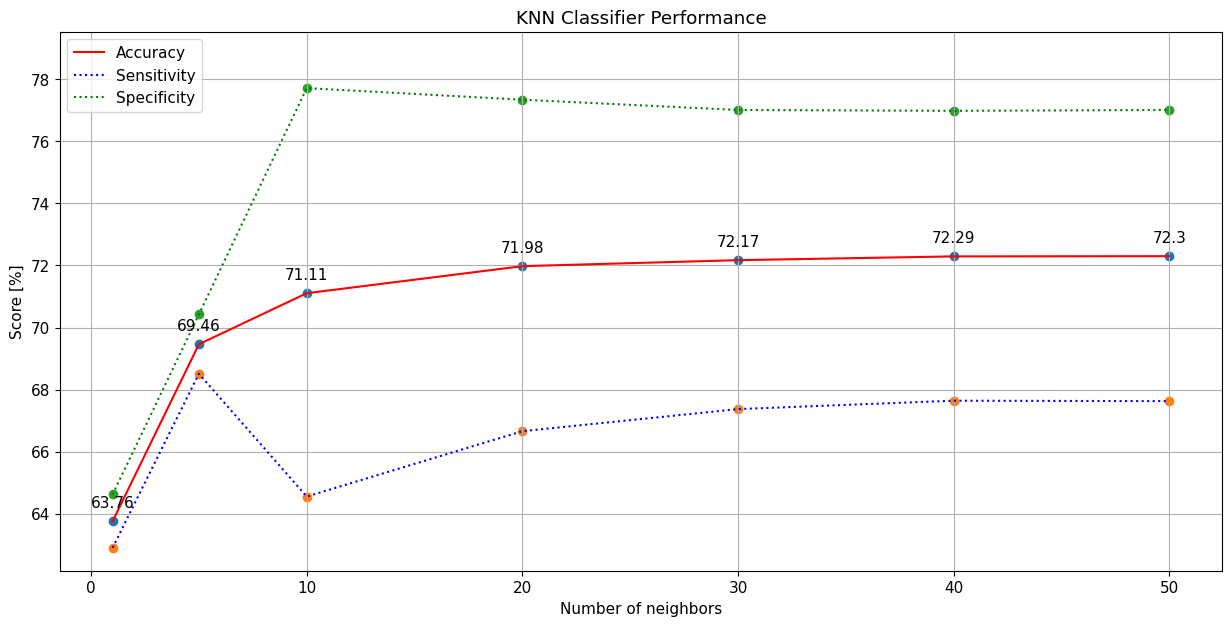

In [71]:
# 5. K-Nearest Neighbors (KNN) - Visualization of the results
# This section visualizes the accuracy, sensitivity, and specificity for different values of K.

plt.figure(figsize=(15, 7))

# Convert lists to numpy arrays for easier manipulation
score_list_knn = np.array(score_list_knn)
score_list_plot_knn = score_list_knn * 100  # Convert accuracy to percentage
true_positive_plot_knn = np.array(true_positive_knn) / sum(y_test) * 100  # Sensitivity in percentage
true_negative_plot_knn = np.array(true_negative_knn) / (len(y_test) - sum(y_test)) * 100  # Specificity in percentage

# Plot the results
plt.plot(nb_neighbor, score_list_plot_knn, 'r-', label='Accuracy')
plt.plot(nb_neighbor, true_positive_plot_knn, 'b:', label='Sensitivity')
plt.plot(nb_neighbor, true_negative_plot_knn, 'g:', label='Specificity')

# Scatter plot to highlight data points
plt.scatter(nb_neighbor, score_list_plot_knn)
plt.scatter(nb_neighbor, true_positive_plot_knn)
plt.scatter(nb_neighbor, true_negative_plot_knn)

# Annotate the data points with their values
for x, y in zip(nb_neighbor, score_list_plot_knn):
    label = "{:.2f}".format(y)
    plt.annotate(str(round(y, 2)),  # Label text
                 (x, y),  # Coordinates for the label
                 textcoords="offset points",  # Text positioning
                 xytext=(0, 10),  # Distance from the point
                 ha='center')  # Horizontal alignment

# Adjust y-axis to improve visualization
plt.ylim(min(score_list_plot_knn) * 0.975, max(score_list_plot_knn) * 1.1)

# Set plot labels and title
plt.xlabel('Number of neighbors')
plt.ylabel('Score [%]')
plt.title('KNN Classifier Performance')

# Display legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [72]:
# 5. K-Nearest Neighbors (KNN) - Finding the optimal K for highest accuracy
# This section finds the value of K that gives the highest accuracy and calculates the sensitivity for k=50.

# Find the maximum accuracy from the score list and the corresponding index
KNN_acc = max(score_list_knn)
max_index = np.argmax(score_list_knn)

# Get the value of K that corresponds to the highest accuracy
max_nb_neighbor = nb_neighbor[max_index]

# Store the highest accuracy and the optimal classifier
max_score_temp = KNN_acc
opt_temp_classifier = KNeighborsClassifier(max_nb_neighbor)

# Print the highest accuracy and corresponding value of K
print(f'The highest accuracy of: {round(KNN_acc, 4) * 100}% is achieved when considering {max_nb_neighbor} Neighbors')

# Find the index where k=50 is the closest in the list of neighbors
index_k50 = min(range(len(nb_neighbor)), key=lambda i: abs(nb_neighbor[i] - 50))

# Get the sensitivity (True Positive Rate) for the closest k value to 50
tpr_KNN_per = true_positive_plot_knn[index_k50]
tpr_KNN = tpr_KNN_per / 100  # Convert to a decimal

# Output the sensitivity at k=50 (or the closest k)
print(f"Sensitivity at k=50 (or closest k): {round(tpr_KNN_per, 2)}%")


The highest accuracy of: 72.3% is achieved when considering 50 Neighbors
Sensitivity at k=50 (or closest k): 67.63%


In [73]:
# Create copies of the original data for further processing
my_data_xx = my_data_4.copy()  # Copy of the data for feature selection
my_data_xy = my_data_scaled.copy()  # Scaled version of the data

# BACKWARD STEPWISE SELECTION (BSS) for feature selection
all_features = my_data_xy.columns  # Get all columns
all_features = all_features.drop(['cardio'])  # Drop the target column 'cardio'

# Weighting features based on their correlation with the target variable 'cardio'
corr_list = my_data_xy.corrwith(my_data_xy['cardio'])  # Calculate correlation of each feature with 'cardio'
corr_list.drop(['cardio'], inplace=True)  # Drop the correlation of 'cardio' with itself

# Adjusting the features by multiplying with the absolute value of the correlation
for column in all_features:
    X[column] = X[column] * np.abs(corr_list[column])

# Define the target and feature columns
label_column = 'cardio'  # Target variable
feature_columns = [c for c in my_data_xx.columns if c != label_column]  # List of feature columns

# Initialize KNN classifier with the optimal number of neighbors
clf_KNN_BSS = KNeighborsClassifier(max_nb_neighbor)

# Set up cross-validation using KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=0)  # 5-fold cross-validation


In [74]:
# Target feature
y = final_data['cardio']  


In [75]:
# Function to calculate the base accuracy using the median value of the target variable
def get_base_acc(y):
    # Create predictions by setting all values to the median of the target variable
    predictions = [np.median(y)] * len(y)
    # Calculate and return the accuracy score by comparing predictions to the actual values
    return accuracy_score(y, predictions)


# Function to perform k-fold cross-validation and calculate the mean accuracy score
def k_fold_acc(X, y, classifier, kfold):
    # Perform cross-validation and return the mean accuracy score
    scores = cross_validate(classifier, X, y, scoring='accuracy', cv=kfold)
    return np.mean(scores['test_score'])


In [76]:
# Function to perform backward stepwise feature selection
def backward_stepwise_selection(X, y, classifier, kfold, all_features):
    # Initialize the current accuracy using k-fold cross-validation
    current_acc = k_fold_acc(X, y, classifier, kfold)

    # Start with all features
    current_features = np.arange(len(feature_columns)) 
    
    # Track the best accuracy and features
    best_acc = current_acc
    best_features = current_features[:]
    
    # Loop until there are no features left to remove
    while len(current_features) > 0:

        non_selected_feature = None
        
        # Check if removing a feature improves accuracy
        for feature in current_features:

            # Remove the current feature and calculate new accuracy
            new_features = np.delete(current_features, np.where(current_features == feature))
            acc = k_fold_acc(X[all_features[new_features]], y, classifier, kfold)
            
            # If accuracy improves, track the feature to remove
            if acc > current_acc:
                non_selected_feature = feature
                current_acc = acc
        
        # Remove the feature that improves accuracy when excluded
        if non_selected_feature is not None:
            current_features = np.delete(current_features, np.where(current_features == non_selected_feature))
        else:
            # If no feature improves accuracy, terminate the loop
            break
    
    # Return the selected features if accuracy is better than the baseline
    if current_acc > get_base_acc(y):
        return current_features, current_acc
    else:
        # Otherwise, return an empty set of features and baseline accuracy
        return [], get_base_acc(y)


In [77]:
final_data.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,BMI,smoke,active,alco,cardio
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,0.671386,0.349648,0.546928,0.408765,0.504622,0.466767,0.183499,0.113267,0.343646,0.088159,0.803718,0.053790,0.499771
std,0.191047,0.476862,0.084386,0.090957,0.074662,0.086142,0.340167,0.286177,0.106680,0.283528,0.397187,0.225604,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.531630,0.000000,0.489362,0.350318,0.473684,0.454545,0.000000,0.000000,0.270492,0.000000,1.000000,0.000000,0.000000
50%,0.689508,0.000000,0.553191,0.394904,0.473684,0.454545,0.000000,0.000000,0.321721,0.000000,1.000000,0.000000,0.000000
75%,0.815254,1.000000,0.606383,0.458599,0.561404,0.545455,0.500000,0.000000,0.397541,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [78]:
print(type(y), y.shape, y.head())


<class 'pandas.core.series.Series'> (69976,) 0    0
1    1
2    1
3    1
4    0
Name: cardio, dtype: int64


In [80]:
# # Calling the backward stepwise selection function
# features, accuracy = backward_stepwise_selection(X_scaled_mm, y_scaled_mm, clf_KNN_BSS, kfold, all_features)

#Takes a long time to run

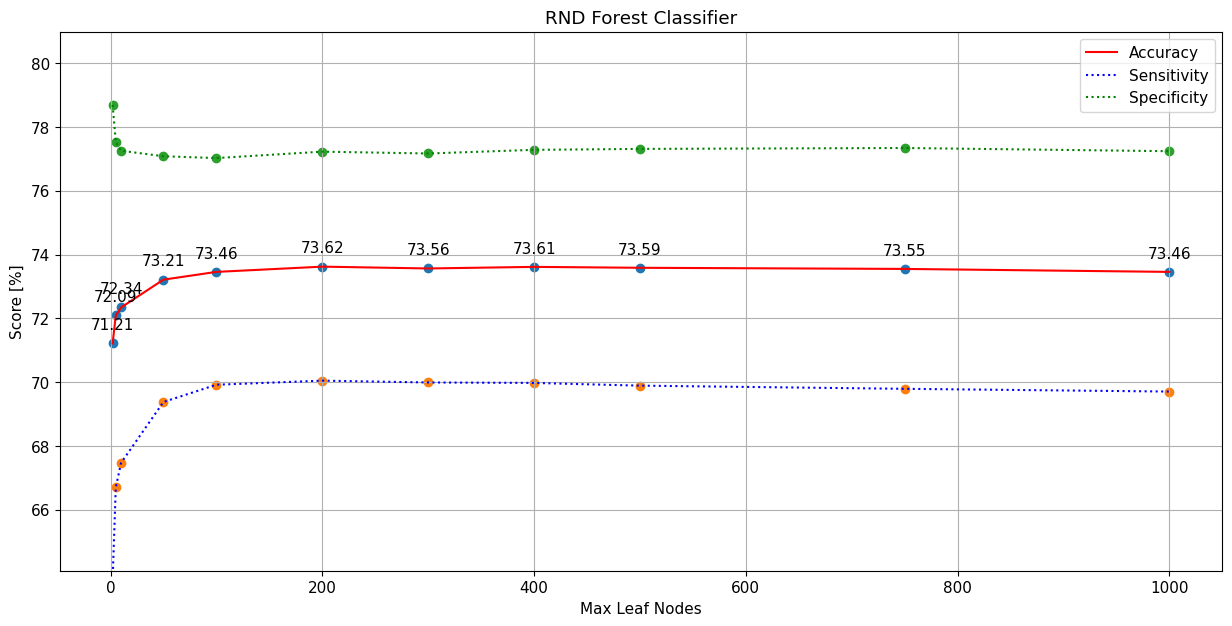

In [81]:
# 6. Random Forest Classifier
viewer_mode = True
rndF_classifiers = []

if viewer_mode:
    # Defining different values for the number of max leaf nodes
    n_ests = [2, 5, 10, 50, 100, 200, 300, 400, 500, 750, 1000]
    for n_est in n_ests:  # Appending classifiers with different max leaf nodes
        rndF_classifiers.append(RandomForestClassifier(n_estimators=500, max_depth=20, max_features='sqrt', max_leaf_nodes=n_est, random_state=0))

    # Initializing lists to store accuracy, true positive rate (TPR), and other performance metrics
    acc_list = []
    tpr_list = []
    report_list = []
    true_positive = []
    true_negative = []

    # Fitting the classifiers and calculating performance metrics
    for clf in rndF_classifiers:
        clf.fit(X_train, y_train)

        # Making predictions
        y_predict = clf.predict(X_test)
        y_predicted = np.array(y_predict > 0.5, dtype=float)

        # Calculating accuracy and confusion matrix
        rndForest_acc = accuracy_score(y_test, y_predicted)
        cm = confusion_matrix(y_test, y_predicted)
        rndForest_tpr = cm[1][1] / (cm[1][0] + cm[1][1])
        rndForest_report = classification_report(y_test, y_predicted)

        # Storing the results
        acc_list.append(rndForest_acc)
        tpr_list.append(rndForest_tpr)
        report_list.append(rndForest_report)
        true_positive.append(cm[1][1])
        true_negative.append(cm[0][0])

    # Visualization of performance metrics
    plt.figure(figsize=(15, 7))
    ax = ax
    score_list = np.array(acc_list)
    score_list_plot = score_list * 100
    true_positive_plot = np.array(true_positive) / sum(y_test) * 100
    true_negative_plot = np.array(true_negative) / (len(y_test) - sum(y_test)) * 100
    plt.plot(n_ests, score_list_plot, 'r-')
    plt.plot(n_ests, true_positive_plot, 'b:')
    plt.plot(n_ests, true_negative_plot, 'g:')
    plt.scatter(n_ests, score_list_plot)
    plt.scatter(n_ests, true_positive_plot)
    plt.scatter(n_ests, true_negative_plot)
    for x, y in zip(n_ests, score_list_plot):
        label = "{:.2f}".format(y)
        plt.annotate(str(round(y, 2)),  # This is the text
                     (x, y),  # These are the coordinates to position the label
                     textcoords="offset points",  # How to position the text
                     xytext=(0, 10),  # Distance from text to points (x, y)
                     ha='center')

    # Adjusting the plot limits and labels
    plt.ylim(min(score_list_plot) * 0.9, max(score_list_plot) * 1.1)
    plt.xlabel('Max Leaf Nodes')
    plt.ylabel('Score [%]')
    plt.title('RND Forest Classifier')
    plt.legend(['Accuracy', 'Sensitivity', 'Specificity'])
    plt.grid(True)
    plt.show()

else:
    # Grid search for hyperparameter tuning
    rndForestClassifier = GridSearchCV(estimator=RandomForestClassifier(random_state=0), 
                                       param_grid={'n_estimators': [500], 'max_features': ['sqrt'], 'max_depth': [20], 'max_leaf_nodes': [500, 1000, 1500]}, 
                                       cv=5, scoring=['accuracy', 'recall'], refit='accuracy').fit(X_train, y_train)
    print(rndForestClassifier.best_estimator_)
    param_selection = rndForestClassifier.cv_results_['params']
    test_scores = rndForestClassifier.cv_results_['mean_test_score']
    
    # Displaying the best hyperparameters and test scores
    for i in param_selection:
        print(i)
    print(test_scores)


Leaf Nodes = 200
Accuracy = 0.7362103458130894
Sensitivity (TPR) = 0.7004837791690381

 Confusion matrix 
 

              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6968
           1       0.76      0.70      0.73      7028

    accuracy                           0.74     13996
   macro avg       0.74      0.74      0.74     13996
weighted avg       0.74      0.74      0.74     13996



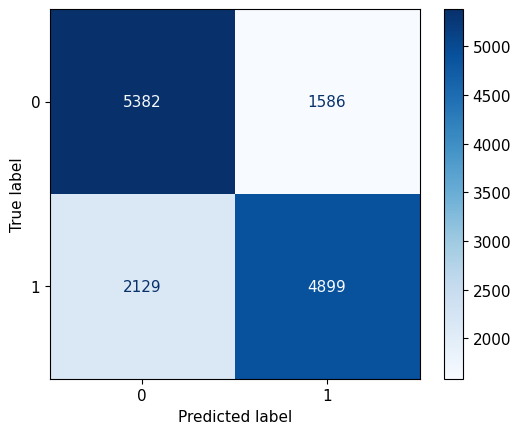

In [82]:
# If viewer_mode is True, we evaluate the best Random Forest model
if viewer_mode:
    # Get the best accuracy and corresponding leaf nodes
    rf_acc = max(acc_list)  # Consistent naming for accuracy
    max_index = np.argmax(acc_list)
    max_nest = n_ests[max_index]
    rf_tpr = tpr_list[max_index]  # Consistent naming for sensitivity (TPR)
    rf_report = report_list[max_index]
    rf_classifier = rndF_classifiers[max_index]  # Consistent naming for the classifier

    # Print the results
    print('Leaf Nodes =', max_nest)
    print('Accuracy =', rf_acc)
    print('Sensitivity (TPR) =', rf_tpr)
  
    print('\n Confusion matrix \n \n')
    print(rf_report)

    # Display the confusion matrix
    disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp_rf.plot(cmap='Blues')  # You can change the color map if needed
    plt.show()
else:
    # If viewer_mode is False, use the best Random Forest model to make predictions
    y_predict = rf_classifier.predict(X_test)  # Consistent naming for the classifier
    y_predicted = np.array(y_predict > 0.5, dtype=float)

    # Calculate accuracy and sensitivity (TPR)
    rf_acc = accuracy_score(y_test, y_predicted)  # Consistent naming for accuracy
    rf_report = classification_report(y_test, y_predicted)  # Consistent naming for report
    rf_cm = confusion_matrix(y_test, y_predicted)  # Consistent naming for confusion matrix
    rf_tpr = rf_cm[1][1] /(rf_cm[1][0] + rf_cm[1][1])  # Consistent naming for sensitivity (TPR)

    # Print the results
    print('Accuracy =', rf_acc)
    print('Sensitivity (TPR) =', rf_tpr)
  
    print('\n Confusion matrix \n \n')
    print(rf_report)

    # Display the confusion matrix
    disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=clf.classes_)  # Consistent naming for confusion matrix
    disp_rf.plot(cmap='Blues')  # You can change the color map if needed
    plt.show()


In [83]:
# 7. If viewer_mode is True, print a message indicating that SVM takes a long time
if viewer_mode:
    print("Support Vector Classifier takes very long.")
else:
    # SVM regularization parameter
    C = 1.0

    # Define the models
    models = (
        svm.SVC(kernel='linear', C=C),
        svm.SVC(kernel='rbf', gamma=0.7, C=C),
        svm.SVC(kernel='poly', degree=3, gamma='auto', C=C)
    )

    # List to store accuracy for each model
    accuracy_svc = []

    # Loop through each model, train, and calculate accuracy
    for clf in models: 
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Store accuracy for each model
        accuracy_svc.append(accuracy_score(y_test, y_pred))
        print(f"Accuracy for {clf.kernel} kernel: ", accuracy_score(y_test, y_pred))


Support Vector Classifier takes very long.


In [84]:
if viewer_mode:
    # Assign values for the highest accuracy and true positive rate for SVC
    max_accuracy_svc = 0.734126
    true_positive_svc = 0.660243
    print('Support Vector Classifier with highest accuracy: Polynomial')
    print('Accuracy =', max_accuracy_svc)
    print('Sensitivity (TPR) =', true_positive_svc)
else:
    # List of SVM model types
    svc_clf_list = ['Linear', 'Radial Basis Function', 'Polynomial']

    # Get the maximum accuracy and the index of the best model
    max_accuracy_svc = max(accuracy_svc)
    max_svc_index = np.argmax(accuracy_svc)

    # Get the best SVM model based on the index
    svc_clf = models[max_svc_index]
    svc_clf.fit(X_train, y_train)

    # Make predictions and generate classification report
    y_predict = svc_clf.predict(X_test)
    svc_report = classification_report(y_test, y_predict)

    # Confusion matrix and true positive rate (TPR)
    cm_svc = confusion_matrix(y_test, y_predict)
    true_positive_svc = cm_svc[1][1] / sum(y_test)

    # Print results
    print('Accuracy =', max_accuracy_svc)
    print('Sensitivity (TPR) =', true_positive_svc)
    print('Support Vector Classifier with highest accuracy:', svc_clf_list[max_svc_index])

    print('\nConfusion matrix\n')
    disp_svc_clf = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=svc_clf.classes_)
    disp_svc_clf.plot(cmap='Blues')  # You can change the color map if needed
    plt.show()


Support Vector Classifier with highest accuracy: Polynomial
Accuracy = 0.734126
Sensitivity (TPR) = 0.660243


In [87]:
# Conclusion #
####################

# Collect results
tpr_weight = 0.25
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear Discriminant analysis', 'Decision Tree', 
              'GradientBoostingClassifier', 'Nearest Neighbor', 'Random Forest', 'Support Vector Classifier'],
    'Accuracy': [logreg_acc, lda_acc, dtree_tuned_acc, boosting_acc, KNN_acc, rf_acc, max_accuracy_svc],
                    
    'Sensitivity' : [tpr_logreg, tpr_lda, tpr_dtree_tuned, tpr_boost, tpr_KNN, rf_tpr, true_positive_svc],
    'Objective Value' : [logreg_acc + tpr_logreg * tpr_weight, lda_acc + tpr_lda * tpr_weight, dtree_tuned_acc + tpr_dtree_tuned * tpr_weight,
                         boosting_acc + tpr_boost * tpr_weight, KNN_acc + tpr_KNN * tpr_weight, 
                         rf_acc + rf_tpr * tpr_weight,
                         max_accuracy_svc + true_positive_svc * tpr_weight]
})

models


,Model,Accuracy,Sensitivity,Objective Value
0,Logistic Regression,0.726922,0.674161,0.895462
1,Linear Discriminant analysis,0.725564,0.662351,0.891152
2,Decision Tree,0.733352,0.684974,0.904596
3,GradientBoostingClassifier,0.736210,0.700199,0.911260
4,Nearest Neighbor,0.722992,0.676295,0.892066
5,Random Forest,0.736210,0.700484,0.911331
6,Support Vector Classifier,0.734126,0.660243,0.899187


In [89]:
# Collect results for plotting
df_plotting = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear Discriminant analysis', 'Decision Tree', 
              'GradientBoostingClassifier', 'Nearest Neighbor', 'Random Forest', 'Support Vector Classifier', 
              'Logistic Regression', 'Linear Discriminant analysis', 'Decision Tree', 
              'GradientBoostingClassifier', 'Nearest Neighbor', 'Random Forest', 'Support Vector Classifier'],
    'Values': [logreg_acc, lda_acc, dtree_tuned_acc, boosting_acc, KNN_acc, rf_acc, max_accuracy_svc,
             tpr_logreg, tpr_lda, tpr_dtree_tuned, tpr_boost, tpr_KNN, rf_tpr, true_positive_svc],
    'Type': ['Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', 
             'Sensitivity', 'Sensitivity', 'Sensitivity', 'Sensitivity',  'Sensitivity', 'Sensitivity', 'Sensitivity']
})


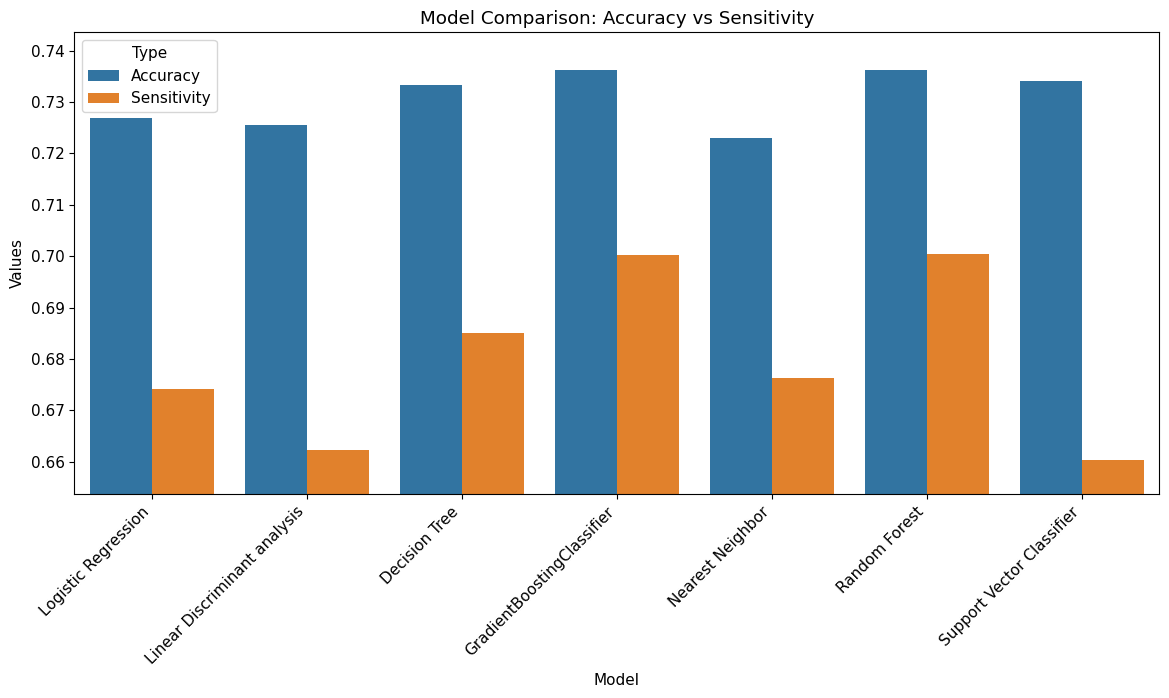

In [90]:
# Plot result comparison
plt.figure(figsize=(14,6))
sns.barplot(x=df_plotting['Model'], y=df_plotting['Values'], hue=df_plotting['Type'], orient="v")
plt.ylim(min(df_plotting['Values']) * 0.99, max(df_plotting['Values']) * 1.01)
plt.xticks(rotation=45, ha='right')  # Rotate the model names for better readability
plt.title('Model Comparison: Accuracy vs Sensitivity')
plt.show()


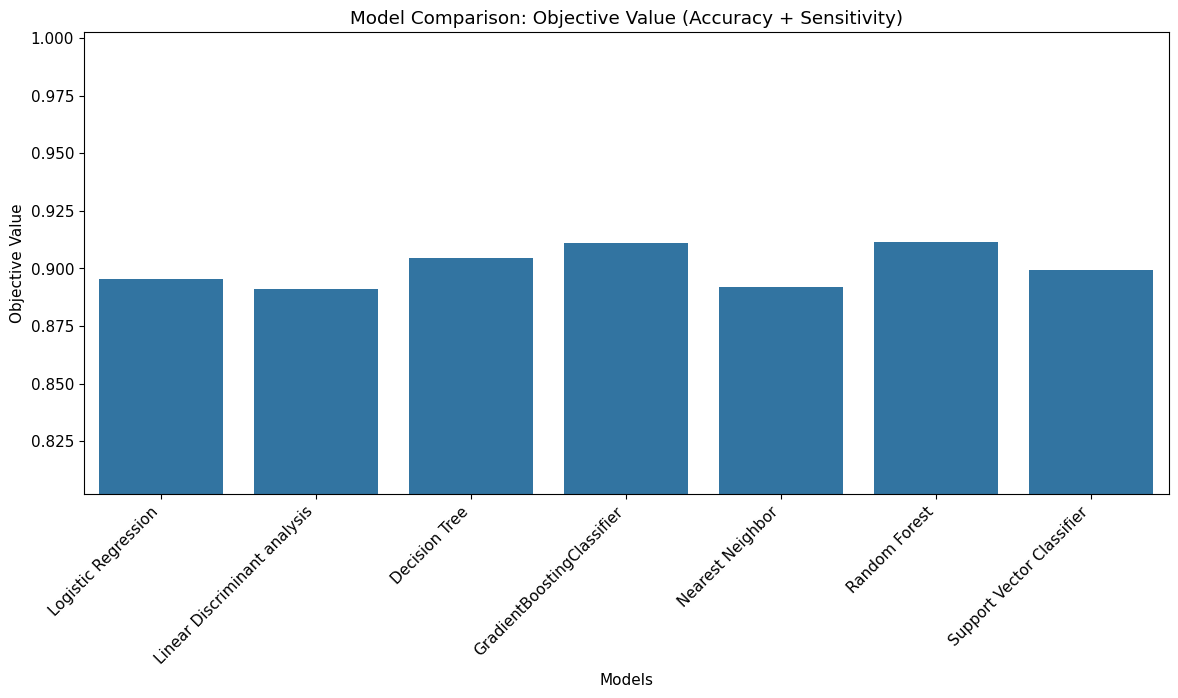

In [91]:
# Plot result comparison
plt.figure(figsize=(14,6))
sns.barplot(x=models['Model'], y=models['Objective Value'], orient="v")

# Adjusting the y-axis limits to make the plot more visually appealing
plt.ylim(min(models['Objective Value']) * 0.9, max(models['Objective Value']) * 1.1)

# Rotating x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adding title and labels for clarity
plt.title('Model Comparison: Objective Value (Accuracy + Sensitivity)')
plt.xlabel('Models')
plt.ylabel('Objective Value')

# Display the plot
plt.show()
